In [1]:
import qiskit_metal as metal
from qiskit_metal import designs
from qiskit_metal import MetalGUI, Dict 

In [2]:
%reload_ext autoreload 
%autoreload 2

In [3]:
%metal_heading Routing 101

In [4]:
design = designs.DesignPlanar()
design.overwrite_enabled = True 

design.variables['cpw_width'] = '10 um' 
design.variables['cpw_gap'] = '6 um'

gui = MetalGUI(design)

08:00PM 20s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: Populating font family aliases took 177 ms. Replace uses of missing font family "Courier" with one that exists to avoid this cost. 



In [18]:
# for pins
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround 

# for routing 
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight 
from qiskit_metal.qlibrary.tlines.framed_path import RouteFramed
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander 

# for jogs
from collections import OrderedDict 

To remove the complexity of large QComponents, we will only use `OpenToGround` QComponent to establish pins. We want to initialize a dictionary of type `Dict` as follows. We will later update this dictionary as needed using the simpler dot notation. 

In [6]:
pin_opt = Dict(
    pin_inputs=Dict(
        start_pin=Dict(
            component='open1i', 
            pin='open',
        ), 
        end_pin=Dict(
            component='open1o', 
            pin='open', 
        ), 
    ),
)

In [7]:
%metal_print Example 1: Straight Routing Between Two Pins

First, we make sure our designs has two pins to connect to. 

In [8]:
design.delete_all_components()

otg11 = OpenToGround(design, 'open1i')
otg12 = OpenToGround(design, 'open1o') 

otg11.options.update(
    {
        'pos_x': '0mm', 
        'pos_y': '1mm', 
        'orientation': '180'
    }
)

otg12.options.update(
    {
        'pos_x': '0.5mm', 
        'pos_y': '1mm', 
        'orientation': '0'
    }
)

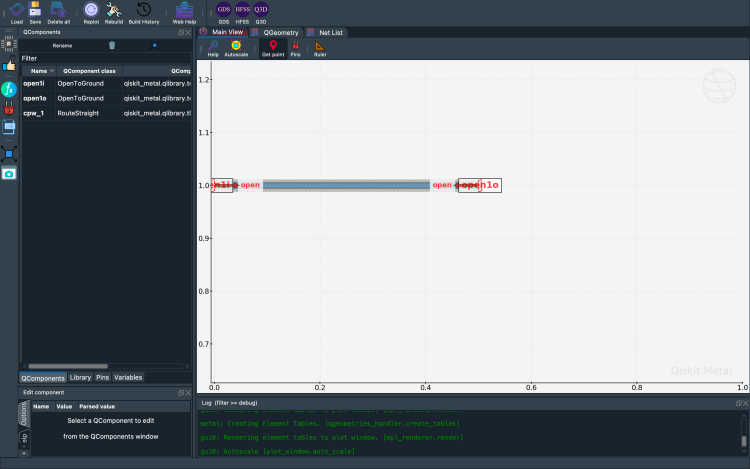

In [9]:
# creating the route 
route1 = RouteStraight(design, 'cpw_1', pin_opt)

gui.rebuild()
gui.autoscale() 
gui.highlight_components(
    ['open1i', 'open1o'] 
)

gui.screenshot()

In [10]:
%metal_print Example 2: Any Direction 

Let's add a few pins that we can use to connect in pairs. We here align them following a variety of orientations.

In [11]:
otg21 = OpenToGround(design, 'open2i', options=dict(pos_x='0mm',  pos_y='2mm', orientation='90'))
otg22 = OpenToGround(design, 'open2o', options=dict(pos_x='0mm',  pos_y='1.5mm', orientation='-90'))
otg31 = OpenToGround(design, 'open3i', options=dict(pos_x='0.35mm',  pos_y='1.55mm', orientation='45'))
otg32 = OpenToGround(design, 'open3o', options=dict(pos_x='0mm',  pos_y='1.2mm', orientation='-135'))
otg41 = OpenToGround(design, 'open4i', options=dict(pos_x='0mm',  pos_y='0.8mm', orientation='135'))
otg42 = OpenToGround(design, 'open4o', options=dict(pos_x='0.35mm',  pos_y='0.45mm', orientation='-45'))

In [12]:
gui.rebuild() 
gui.autoscale()

Then we connect a pair of pins using a straight route. Notice how we update the `pin_opt` component names to a new pair for each new `RouteStraight`. We can only use a pin for one single connection, and will get an error if we try to connect a second route to the same pin. 

In [13]:
pin_opt.pin_inputs.start_pin.component = 'open2i' 
pin_opt.pin_inputs.end_pin.component = 'open2o' 
route2 = RouteStraight(design, 'cpw_2', pin_opt) 


pin_opt.pin_inputs.start_pin.component = 'open3i'
pin_opt.pin_inputs.end_pin.component = 'open3o' 
route3 = RouteStraight(design, 'cpw_3', pin_opt)


pin_opt.pin_inputs.start_pin.component = 'open4i'
pin_opt.pin_inputs.end_pin.component = 'open4o'
route4 = RouteStraight(design, 'cpw_4', pin_opt)

gui.rebuild() 
gui.autoscale() 

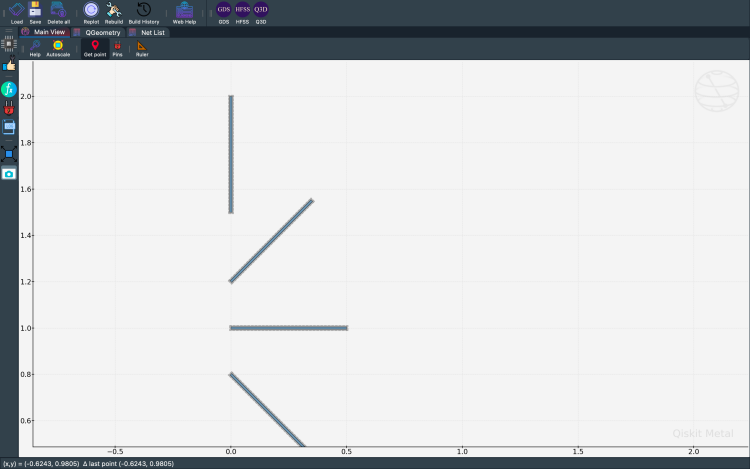

In [14]:
gui.toggle_docks(True)
gui.screenshot()

In [15]:
%metal_print Example 3: Angles and leads 

If the two pins to connect are not facing each other, the router will create the necessary jobs. Here is a simple example that shows 45 degree jogs. 

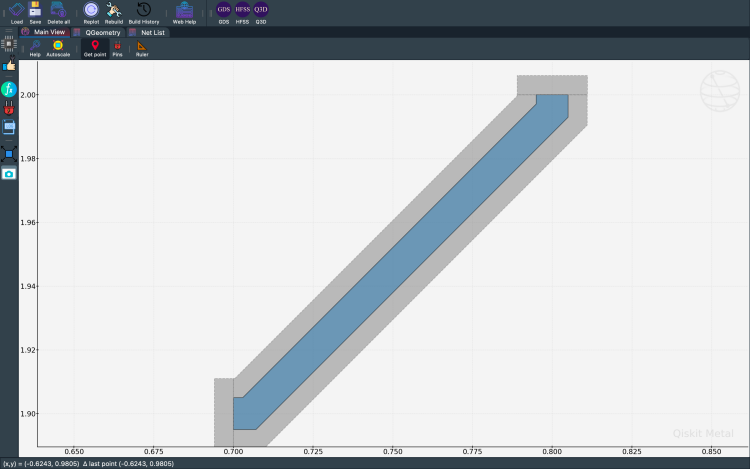

In [16]:
otg51 = OpenToGround(design, 'open5i', options=dict(pos_x='0.7mm', pos_y='1.9mm', orientation='180'))
otg52 = OpenToGround(design, 'open5o', options=dict(pos_x='0.8mm', pos_y='2.0mm', orientation='90'))

pin_opt.pin_inputs.start_pin.component = 'open5i'
pin_opt.pin_inputs.end_pin.component = 'open5o'
route5 = RouteStraight(design, 'cpw_5', pin_opt) 

gui.rebuild() 
gui.zoom_on_components(['cpw_5'])
gui.screenshot()

Let's make another connection. This time, we add a lead extension to both pins. An extension is a route segment that begins from the pin coordinates and extends straight in the pin direction by the given length. 

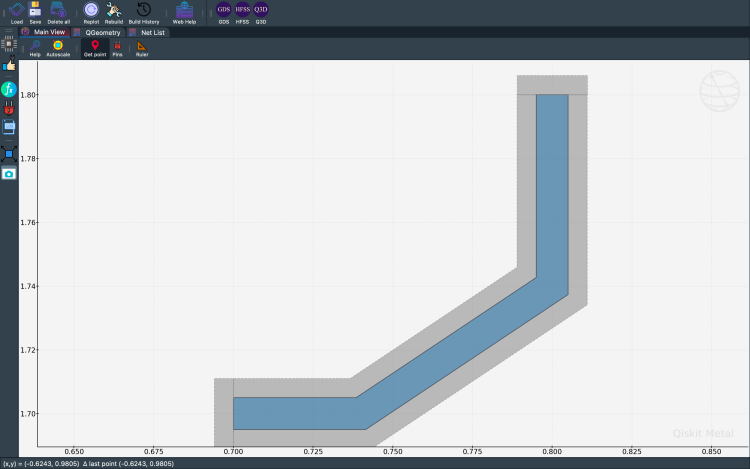

In [23]:
otg61 = OpenToGround(design, 'open6i', options=dict(pos_x='0.7mm', pos_y='1.7mm', orientation='180'))
atg62 = OpenToGround(design, 'open6o', options=dict(pos_x='0.8mm', pos_y='1.8mm', orientation='90'))

pin_opt.pin_inputs.start_pin.component = 'open6i'
pin_opt.pin_inputs.end_pin.component = 'open6o' 

pin_opt.lead.start_straight = '0.04mm'
pin_opt.lead.end_straight = '0.06mm' 

pin_opt.total_length='5mm'

route6 = RouteStraight(design, 'cpw_6', pin_opt) 

gui.rebuild() 
gui.zoom_on_components(['cpw_6'])
gui.screenshot()

In [ ]:
%metal_print Example 4: 90 deg angles

In [25]:
%metal_print Example 4: 90 deg angles

In most applications you might want to limit the jogs to 90 deg angles. 
In the following example we will use the same `pin_opts` of the previous 
example, but we replace `RouteStraight` with `RouteFramed`. You will 
notice that our route now has only one 90 deg jog. 

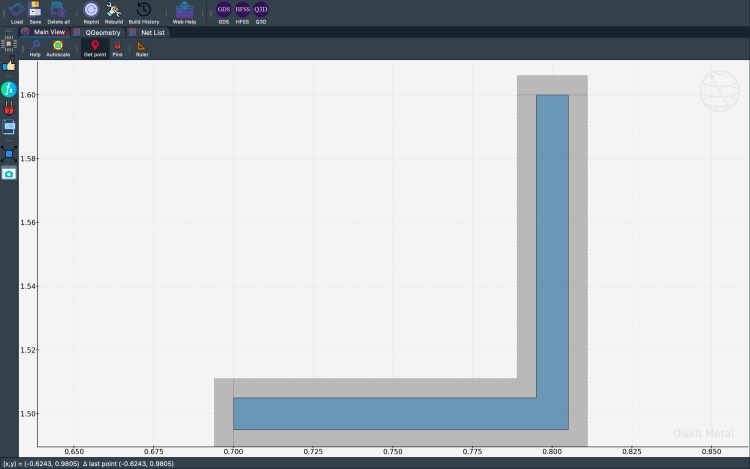

In [26]:
otg71 = OpenToGround(design, 'open7i', options=dict(pos_x='0.7mm',  pos_y='1.5mm', orientation='180'))
otg72 = OpenToGround(design, 'open7o', options=dict(pos_x='0.8mm',  pos_y='1.6mm', orientation='90'))

pin_opt.pin_inputs.start_pin.component = 'open7i'
pin_opt.pin_inputs.end_pin.component = 'open7o'

route7 = RouteFramed(design, 'cpw_7', pin_opt) 

gui.rebuild() 
gui.zoom_on_components(['cpw_7']) 
gui.screenshot()

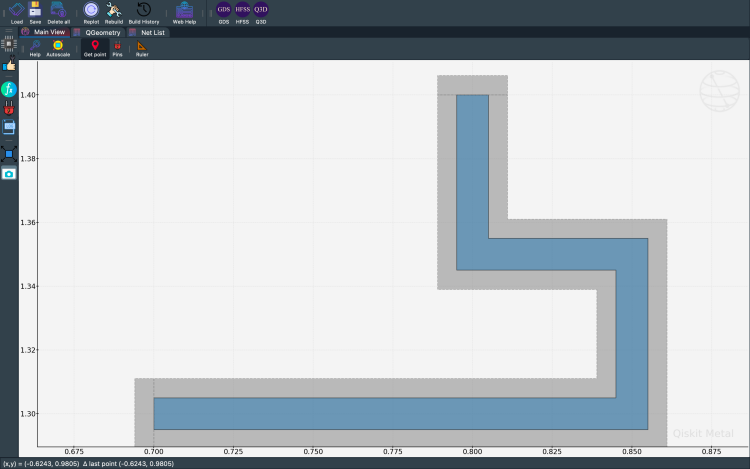

In [27]:
otg81 = OpenToGround(design, 'open8i', options=dict(pos_x='0.7mm',  pos_y='1.3mm', orientation='180'))
otg82 = OpenToGround(design, 'open8o', options=dict(pos_x='0.8mm',  pos_y='1.4mm', orientation='90'))

pin_opt.pin_inputs.start_pin.component = 'open8i'
pin_opt.pin_inputs.end_pin.component = 'open8o'

pin_opt.lead.start_straight = '0.15mm'
pin_opt.lead.end_straight = '0.05mm'
route8 = RouteFramed(design, 'cpw_8', pin_opt)

gui.rebuild()
gui.zoom_on_components(['cpw_8'])
gui.screenshot()

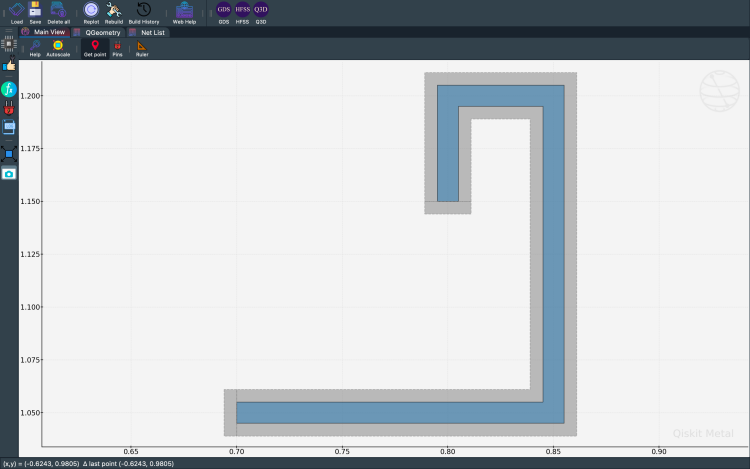

In [30]:
otg91 = OpenToGround(design, 'open9i', options=dict(pos_x='0.7mm',  pos_y='1.05mm', orientation='180'))
otg92 = OpenToGround(design, 'open9o', options=dict(pos_x='0.8mm',  pos_y='1.15mm', orientation='270'))

pin_opt.pin_inputs.start_pin.component = 'open9i'
pin_opt.pin_inputs.end_pin.component = 'open9o'

route9 = RouteFramed(design, 'cpw_9', pin_opt)

gui.rebuild()
gui.zoom_on_components(['cpw_9'])
gui.screenshot()

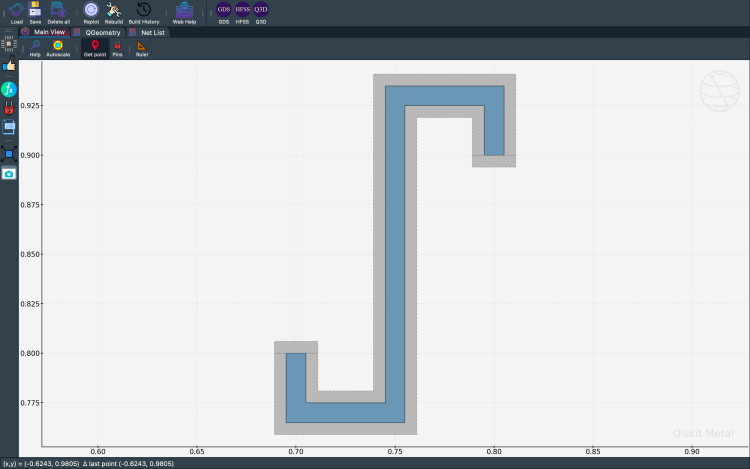

In [31]:
otg101 = OpenToGround(design, 'open10i', options=dict(pos_x='0.7mm',  pos_y='0.8mm', orientation='90'))
otg102 = OpenToGround(design, 'open10o', options=dict(pos_x='0.8mm',  pos_y='0.9mm', orientation='270'))

pin_opt.pin_inputs.start_pin.component = 'open10i'
pin_opt.pin_inputs.end_pin.component = 'open10o'

pin_opt.lead.start_straight = '0.03mm'
pin_opt.lead.end_straight = '0.03mm'
route10 = RouteFramed(design, 'cpw_10', pin_opt)

gui.rebuild()
gui.zoom_on_components(['cpw_10'])
gui.screenshot()

In [32]:
%metal_print Example 5: Tight control on leads and angles

`QRouteLeads` are a "stack" of points that describe in detail the "last-mile" to the pins where the route terminates. These stacks are seeded with the pin coordinates and direction and build incrementally. 

In the previous examples we controlled the QRouteLead points by utilizing the `lead` option inside the `pin_opt` construct. Specifically, we utilized `start_straight` and `end_straight`, which added one point to the respective leads, at the specified distance in the direction specified by the pins. 

We are however not limited to a single aligned extension point. Utilizing the `start_jogged_extension` and `end_jogged_extension` we can specify any number of points to add to the lead stacks. The points are computing by providing an OrderedDict() of steps, expressed as `[angle, distance]` pairs. `distance` is the string describing how long the step needs to be and `angle` describes the direction in which to take the step. 

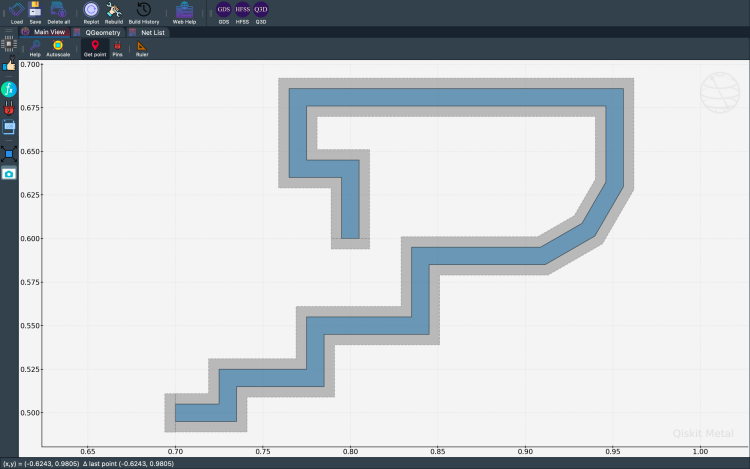

In [38]:
otg111 = OpenToGround(design, 'open11i', options=dict(pos_x='0.7mm', pos_y='0.5mm', orientation='180')) 
otg112 = OpenToGround(design, 'open11o', options=dict(pos_x='0.8mm', pos_y='0.6mm', orientation='270')) 

pin_opt.pin_inputs.start_pin.component = 'open11i' 
pin_opt.pin_inputs.end_pin.component = 'open11o'

# the first step is always straight
# let's define by how much (the minimum is half the route width)
pin_opt.lead.start_straight = '0.03mm' 
pin_opt.lead.end_straight = '0.04mm'

# any subsequent step of the lead_start
jogsS = OrderedDict()
jogsS[0] = ["L", '20um']
jogsS[1] = ["R", '50um']
jogsS[2] = [90, '30um']
jogsS[3] = [-90, '60um']
jogsS[4] = ["90", '40um']
jogsS[5] = ["-90", '70um']
jogsS[6] = ["L30", '30um']
jogsS[7] = ["A,30", '30um']
jogsS[8] = ["left30", '50um']

# single job on the lead_end 
jogsE = OrderedDict() 
jogsE[0] = ['L', '30um'] 

pin_opt.lead.start_jogged_extension = jogsS 
pin_opt.lead.end_jogged_extension = jogsE 
route10 = RouteFramed(design, 'cpw_11', pin_opt) 

gui.rebuild() 
gui.zoom_on_components(['cpw_11']) 
gui.screenshot()